In [1]:
import pandas as pd
import numpy as np

C:\Users\hp\AppData\Local\Temp\ipykernel_15668\2162656668.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data=pd.read_csv("../Data/Wheat_Master_Data_Lowercase_Crop.csv")

In [3]:
data.columns

Index(['crop', 'vegetation_stress_score', 'water_stress_score',
       'soil_stress_score', 'final_stress_percent', 'stress_category',
       'yellow_rust', 'fusarium_head_blight', 'brown_rust', 'powdery_mildew',
       'leaf_blight', 'root_rot', 'smut', 'dominant_Disease', 'growth_stage',
       'das_min', 'das_max', 'gdd_min', 'gdd_max', ' '],
      dtype='object')

In [4]:
data.head()

,crop,vegetation_stress_score,water_stress_score,soil_stress_score,final_stress_percent,stress_category,yellow_rust,fusarium_head_blight,brown_rust,powdery_mildew,leaf_blight,root_rot,smut,dominant_Disease,growth_stage,das_min,das_max,gdd_min,gdd_max,
0,wheat,0.8,0.2,0.2,50.0,Moderate Stress,0.438,0.625,0.375,0.125,0.312,0.250,0.250,fusarium_head_blight,Heading,66,75,1100,1300,NaN
1,wheat,0.8,0.5,0.2,54.5,Moderate Stress,0.000,0.229,0.000,0.064,0.191,0.318,0.191,root_rot,Emergence,6,10,120,180,NaN
2,wheat,0.5,0.2,0.2,35.0,Moderate Stress,0.235,0.411,0.176,0.059,0.118,0.118,0.294,fusarium_head_blight,Heading,66,75,1100,1300,NaN
3,wheat,0.2,0.8,0.8,59.0,Moderate Stress,0.324,0.777,0.388,0.194,0.259,0.130,0.194,fusarium_head_blight,Flowering,75,85,1300,1500,NaN
4,wheat,0.8,0.5,0.5,65.0,High Stress,0.000,0.238,0.000,0.066,0.199,0.331,0.199,root_rot,Emergence,6,10,120,180,NaN


In [5]:
data.columns

Index(['crop', 'vegetation_stress_score', 'water_stress_score',
       'soil_stress_score', 'final_stress_percent', 'stress_category',
       'yellow_rust', 'fusarium_head_blight', 'brown_rust', 'powdery_mildew',
       'leaf_blight', 'root_rot', 'smut', 'dominant_Disease', 'growth_stage',
       'das_min', 'das_max', 'gdd_min', 'gdd_max', ' '],
      dtype='object')

In [6]:
data.describe()

,vegetation_stress_score,water_stress_score,soil_stress_score,final_stress_percent,yellow_rust,fusarium_head_blight,brown_rust,powdery_mildew,leaf_blight,root_rot,smut,das_min,das_max,gdd_min,gdd_max,
count,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,0.0
mean,0.495100,0.495100,0.503539,49.633848,0.263324,0.321239,0.272059,0.222270,0.255505,0.145148,0.120030,59.435572,71.225045,1078.203267,1319.637024,NaN
std,0.245899,0.243561,0.247744,12.746320,0.154900,0.264699,0.145294,0.162535,0.168195,0.184580,0.157323,44.143755,46.727573,835.709080,895.896820,NaN
min,0.200000,0.200000,0.200000,20.000000,0.000000,0.000000,0.000000,0.020000,0.020000,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.200000,0.200000,0.200000,41.000000,0.120000,0.100000,0.140000,0.140000,0.200000,0.060000,0.050000,11.000000,30.000000,200.000000,600.000000,NaN
50%,0.500000,0.500000,0.500000,50.000000,0.300000,0.220000,0.320000,0.180000,0.240000,0.080000,0.060000,66.000000,75.000000,1100.000000,1300.000000,NaN
75%,0.800000,0.800000,0.800000,59.000000,0.350000,0.480000,0.360000,0.240000,0.300000,0.120000,0.100000,86.000000,105.000000,1500.000000,2000.000000,NaN
max,0.800000,0.800000,0.800000,80.000000,0.580000,0.900000,0.550000,0.650000,0.700000,0.720000,0.620000,136.000000,150.000000,2600.000000,2800.000000,NaN


In [7]:
data.shape

(1102, 20)

In [8]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

In [9]:
data.isnull().sum()

crop                          0
vegetation_stress_score       0
water_stress_score            0
soil_stress_score             0
final_stress_percent          0
stress_category               0
yellow_rust                   0
fusarium_head_blight          0
brown_rust                    0
powdery_mildew                0
leaf_blight                   0
root_rot                      0
smut                          0
dominant_Disease              0
growth_stage                  0
das_min                       0
das_max                       0
gdd_min                       0
gdd_max                       0
                           1102
dtype: int64

In [10]:
data.shape

(1102, 20)

In [11]:
crop_encoder = LabelEncoder()
stage_encoder = LabelEncoder()

In [12]:
data["crop_enc"] = crop_encoder.fit_transform(data["crop"])
data["stage_enc"] = stage_encoder.fit_transform(data["growth_stage"])

FEATURE_COLUMNS = [
    "vegetation_stress_score",
    "water_stress_score",
    "soil_stress_score",
    "final_stress_percent",
    "gdd_min",
    "gdd_max",
    "crop_enc",
    "stage_enc"
]

In [13]:
X = data[FEATURE_COLUMNS]

In [14]:
TARGET_COLUMNS = [
    "yellow_rust",
    "brown_rust",
    "fusarium_head_blight",
    "powdery_mildew",
    "leaf_blight",
    "root_rot",
    "smut"
]

In [15]:
y=data[TARGET_COLUMNS]

In [16]:
data = data.dropna(subset=FEATURE_COLUMNS + TARGET_COLUMNS)

In [17]:
data.shape

(1102, 22)

In [18]:
data = data.dropna(subset=FEATURE_COLUMNS + TARGET_COLUMNS)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (881, 8) Test size: (221, 8)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
ann_model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    batch_size=16,
    learning_rate_init=0.001,
    learning_rate="adaptive",
    max_iter=4000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42
)

In [22]:
ann_model.fit(X_train_scaled, y_train)

MLPRegressor(alpha=0.0005, batch_size=16, early_stopping=True,
             hidden_layer_sizes=(256, 128, 64), learning_rate='adaptive',
             max_iter=4000, n_iter_no_change=30, random_state=42,
             validation_fraction=0.15)

In [23]:
y_pred = ann_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)

In [24]:
from sklearn.metrics import r2_score

In [25]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9821704680599929


In [26]:
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Absolute Error (MAE): 0.0135


In [27]:
with open("../Models/disease_probability_ann_multi.pkl", "wb") as f:
    pickle.dump(ann_model, f)

with open("../Models/stress_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../Models/crop_encoder.pkl", "wb") as f:
    pickle.dump(crop_encoder, f)

with open("../Models/stage_encoder.pkl", "wb") as f:
    pickle.dump(stage_encoder, f)

print("✅ Training complete. Multi-disease ANN model saved.")

✅ Training complete. Multi-disease ANN model saved.


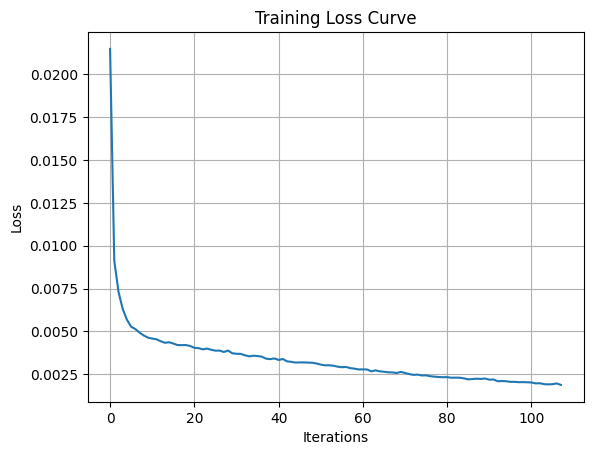

In [28]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure()
plt.plot(ann_model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid()

plt.show()

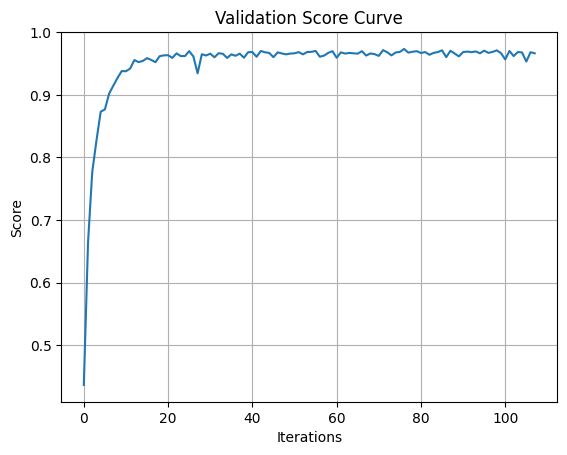

In [29]:
plt.figure()
plt.plot(ann_model.validation_scores_)
plt.title("Validation Score Curve")
plt.xlabel("Iterations")
plt.ylabel("Score")
plt.grid()
plt.show()